# **Acessos por Velocidade Contratada – Banda Larga Fixa**
Disponível em:
https://dados.gov.br/dados/conjuntos-dados/acessos-por-velocidade-contratada-banda-larga-fixa

# **Órgão Responsável pela Publicação**
O dataset é publicado pela Agência Nacional de Telecomunicações (Anatel), órgão regulador responsável pela fiscalização e regulamentação do setor de telecomunicações no Brasil.

# **Descrição do Dataset e Finalidade**
O dataset reúne informações detalhadas sobre a oferta de internet banda larga fixa no Brasil.

Os dados estão organizados por empresa prestadora, município, unidade federativa e faixa de velocidade contratada, permitindo analisar como o serviço está distribuído no território nacional.

O arquivo utilizado neste trabalho corresponde ao **2º trimestre de 2020**, período particularmente relevante por coincidir com o início da pandemia de COVID-19 no Brasil, quando houve aumento expressivo na demanda por internet devido ao trabalho remoto, aulas online e maior consumo de serviços digitais.

A principal finalidade desse conjunto de dados é permitir:

*   O acompanhamento da expansão da infraestrutura de banda larga no país
*   A análise da distribuição das velocidades contratadas entre regiões
*   A identificação de desigualdades no acesso à internet;

Além disso, o dataset possibilita investigar padrões de mercado, como a concentração de acessos em determinadas empresas ou a predominância de certas faixas de velocidade em municípios específicos.

# **Número de Registros e Colunas**
Arquivo 2020-2.csv:

*   Número de registros: 375.008 linhas
*   Número de colunas: 10 variáveis


Colunas identificadas:

1.   razao_social
2.   cnpj
3.   velocidade_contratada_mbps
4.   uf
5.   municipio
6.   codigo_ibge
7.   periodo
8.   acessos
9.   tipo
10.   municipio_uf

# **Significado das Variáveis Mais Importantes**

*   **velocidade_contratada_mbps**: Velocidade da banda larga contratada pelo usuário (em Mbps)
*   **uf**: Unidade da Federação (sigla do estado)
*   **periodo**: Mês e ano de referência no formato AAAA-MM
*   **acessos**: Quantidade de contratos ativos naquela velocidade


# **1. Importação das bibliotecas**

In [ ]:
# 1. Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos
sns.set(style="whitegrid")

# Exibir gráficos no notebook
%matplotlib inline

# **2. Carregamento do dataset**

In [ ]:
# 2. Carregamento do dataset
df = pd.read_csv("2020-2.csv", sep=";", encoding="latin1")

# Visualizar as primeiras linhas
df.head()

,razao_social,cnpj,velocidade_contratada_mbps,uf,municipio,codigo_ibge,periodo,acessos,tipo,municipio_uf
0,RBC - REDE BRASILEIRA DE COMUNICAÇÃO LTDA.,01.766.744/0001-84,1,MG,Alfenas,3101607,2020-04,3.0,INTERNET,Alfenas - MG
1,RBC - REDE BRASILEIRA DE COMUNICAÇÃO LTDA.,01.766.744/0001-84,2,MG,Alfenas,3101607,2020-04,5.0,INTERNET,Alfenas - MG
2,RBC - REDE BRASILEIRA DE COMUNICAÇÃO LTDA.,01.766.744/0001-84,3,MG,Alfenas,3101607,2020-04,4.0,INTERNET,Alfenas - MG
3,RBC - REDE BRASILEIRA DE COMUNICAÇÃO LTDA.,01.766.744/0001-84,4,MG,Alfenas,3101607,2020-04,11.0,INTERNET,Alfenas - MG
4,RBC - REDE BRASILEIRA DE COMUNICAÇÃO LTDA.,01.766.744/0001-84,5,MG,Alfenas,3101607,2020-04,6.0,INTERNET,Alfenas - MG


# **3. Informações gerais do dataset**

In [ ]:
# 3. Informações gerais

# Dimensão do dataset (linhas, colunas)
print("Dimensões do dataset:", df.shape)

# Informações sobre tipos de dados e valores nulos
df.info()

Dimensões do dataset: (375008, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375008 entries, 0 to 375007
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   razao_social                375008 non-null  object 
 1   cnpj                        375008 non-null  object 
 2   velocidade_contratada_mbps  375008 non-null  object 
 3   uf                          375008 non-null  object 
 4   municipio                   375008 non-null  object 
 5   codigo_ibge                 375008 non-null  int64  
 6   periodo                     375008 non-null  object 
 7   acessos                     374963 non-null  float64
 8   tipo                        375008 non-null  object 
 9   municipio_uf                375008 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 28.6+ MB


# **4. Estatísticas Descritivas – Tratamento**

Focaremos nas nas variáveis numéricas mais relevantes:


*   velocidade_contratada_mbps
*   acessos

In [ ]:
# Converter para numérico forçando erros a virarem NaN
df["velocidade_contratada_mbps"] = pd.to_numeric(
    df["velocidade_contratada_mbps"],
    errors="coerce"
)

df["acessos"] = pd.to_numeric(
    df["acessos"],
    errors="coerce"
)

# Remover possíveis NaNs gerados na conversão
df = df.dropna(subset=["velocidade_contratada_mbps", "acessos"])

# Remover valores nulos
df = df[df["velocidade_contratada_mbps"] > 0]

# Corrigir possíveis valores em Kbps
df["velocidade_contratada_mbps"] = np.where(
    df["velocidade_contratada_mbps"] > 1000,
    df["velocidade_contratada_mbps"] / 1000,
    df["velocidade_contratada_mbps"]
)

# Escolhendo as variáveis que queremos analisar
df_numerico = df[["velocidade_contratada_mbps", "acessos"]]
df_numerico.describe()

,velocidade_contratada_mbps,acessos
count,261839.000000,261839.000000
mean,36.380903,261.908082
std,96.746882,3548.708779
min,1.000000,0.000000
25%,2.000000,1.000000
50%,8.000000,4.000000
75%,20.000000,22.000000
max,1000.000000,407142.000000


# **5. Estatísticas Descritivas – Cálculo**

In [ ]:
# Média
media = df_numerico.mean()
print("MÉDIA:\n", media)

# Mediana
mediana = df_numerico.median()
print("\nMEDIANA:\n", mediana)

# Moda
moda = df_numerico.mode().iloc[0]
print("\nMODA:\n", moda)

# Mínimo e Máximo
minimos = df_numerico.min()
maximos = df_numerico.max()

print("MÍNIMOS:\n", minimos)
print("\nMÁXIMOS:\n", maximos)

# Variância e Desvio Padrão
variancia = df_numerico.var()
desvio_padrao = df_numerico.std()

print("VARIÂNCIA:\n", variancia)
print("\nDESVIO PADRÃO:\n", desvio_padrao)

# Quartis
q1 = df_numerico.quantile(0.25)
q2 = df_numerico.quantile(0.50)
q3 = df_numerico.quantile(0.75)

print("Q1 (25%):\n", q1)
print("\nQ2 (50% - Mediana):\n", q2)
print("\nQ3 (75%):\n", q3)

# Intervalo Interquartil
iqr = q3 - q1
print("\nIQR:\n", iqr)

# Valores ausentes
# Contagem de valores nulos por coluna
valores_nulos = df.isnull().sum()

print("VALORES NULOS POR COLUNA:\n")
print(valores_nulos)

# Percentual de valores nulos
percentual_nulos = (df.isnull().sum() / len(df)) * 100

print("\nPERCENTUAL DE VALORES NULOS (%):\n")
print(percentual_nulos)

# Verificar assimetria
df_numerico.skew()

MÉDIA:
 velocidade_contratada_mbps     36.380903
acessos                       261.908082
dtype: float64

MEDIANA:
 velocidade_contratada_mbps    8.0
acessos                       4.0
dtype: float64

MODA:
 velocidade_contratada_mbps    2.0
acessos                       1.0
Name: 0, dtype: float64
MÍNIMOS:
 velocidade_contratada_mbps    1.0
acessos                       0.0
dtype: float64

MÁXIMOS:
 velocidade_contratada_mbps      1000.0
acessos                       407142.0
dtype: float64
VARIÂNCIA:
 velocidade_contratada_mbps    9.359959e+03
acessos                       1.259333e+07
dtype: float64

DESVIO PADRÃO:
 velocidade_contratada_mbps      96.746882
acessos                       3548.708779
dtype: float64
Q1 (25%):
 velocidade_contratada_mbps    2.0
acessos                       1.0
Name: 0.25, dtype: float64

Q2 (50% - Mediana):
 velocidade_contratada_mbps    8.0
acessos                       4.0
Name: 0.5, dtype: float64

Q3 (75%):
 velocidade_contratada_mbps    20.0
acesso

,0
velocidade_contratada_mbps,5.469209
acessos,60.784249


# **6. Visualizações**

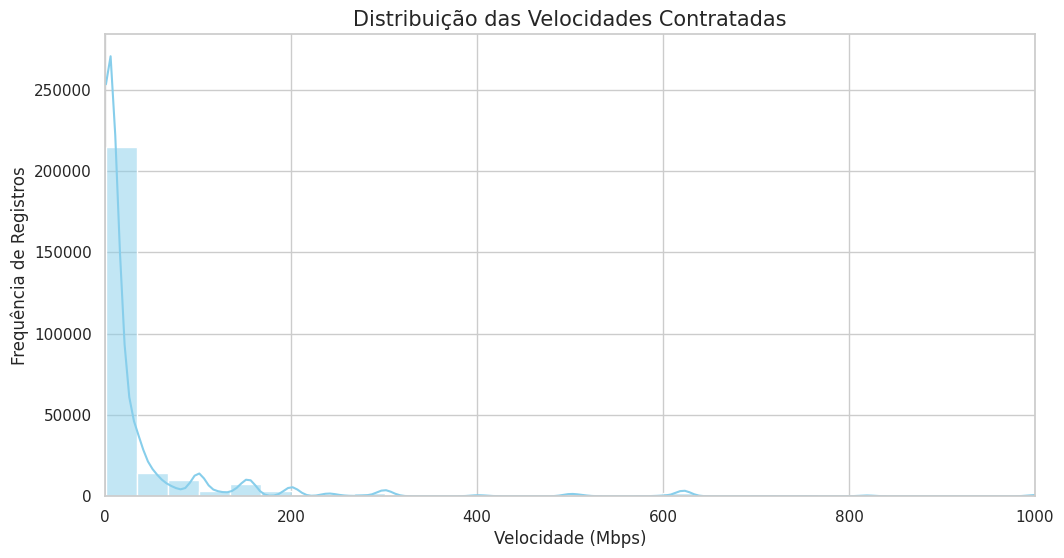

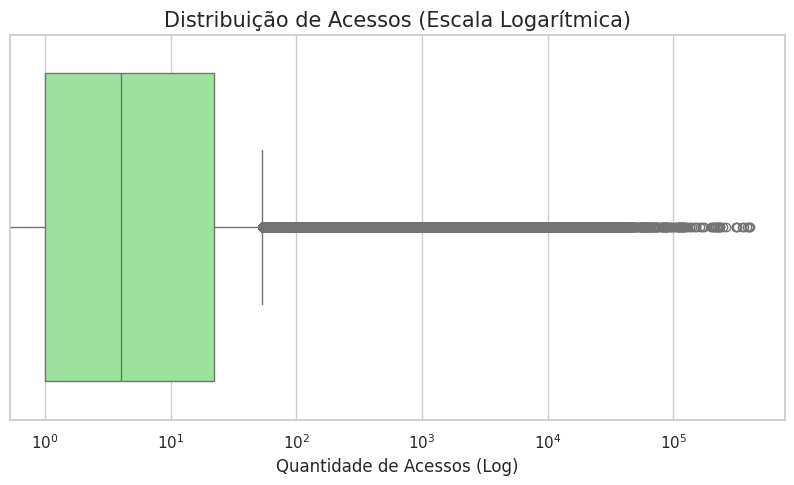

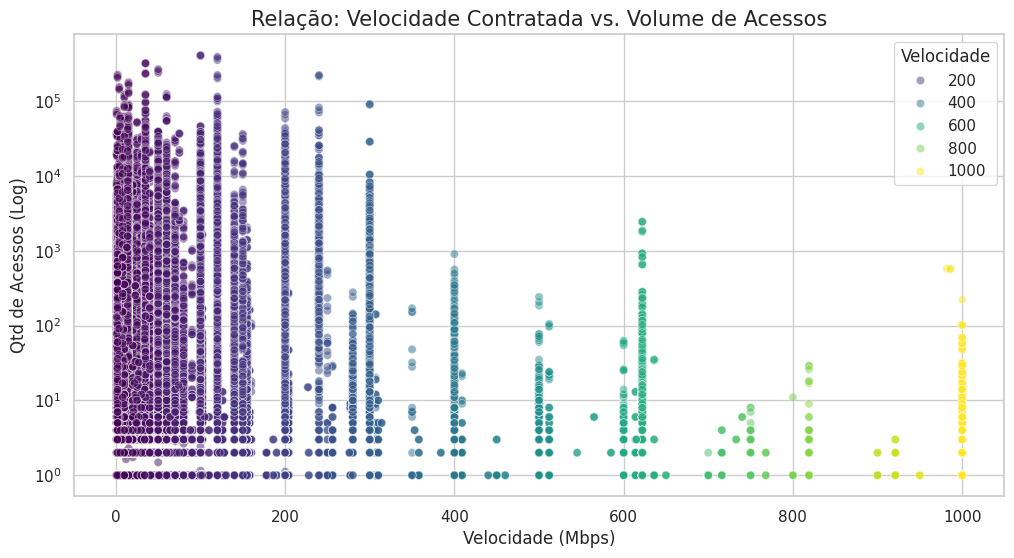

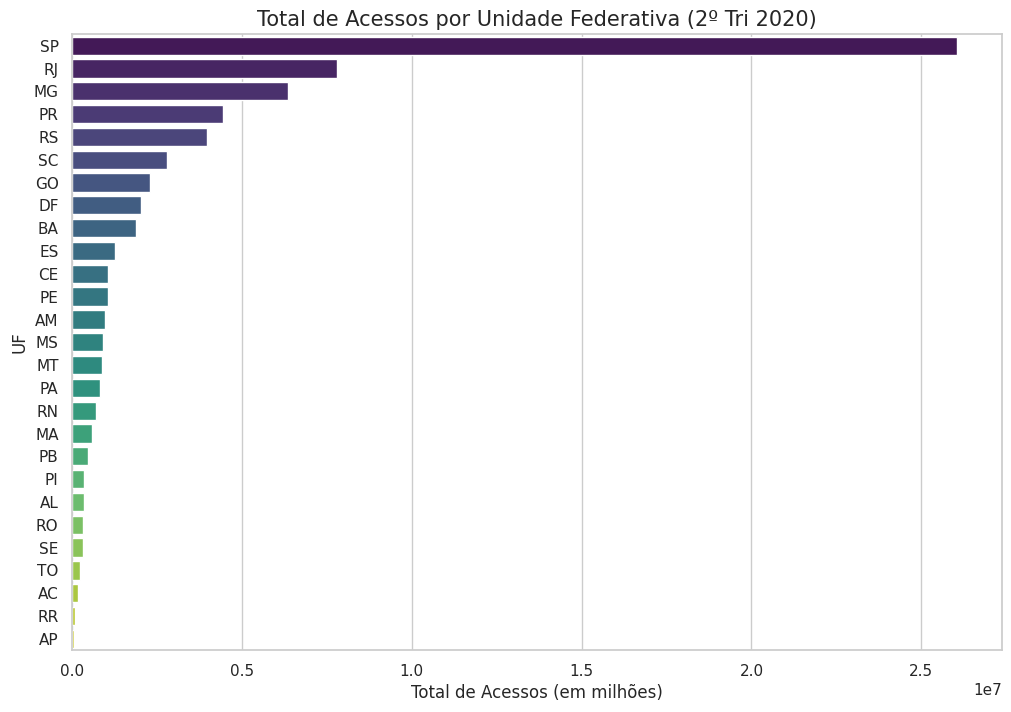

In [ ]:
# 1. Histograma de Velocidade com Densidade (KDE)
plt.figure(figsize=(12, 6))
sns.histplot(df["velocidade_contratada_mbps"], bins=30, kde=True, color='skyblue')
plt.title("Distribuição das Velocidades Contratadas", fontsize=15)
plt.xlabel("Velocidade (Mbps)")
plt.ylabel("Frequência de Registros")
plt.xlim(0, 1000)
plt.show()

# 2. Boxplot de Acessos com Escala Logarítmica
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["acessos"], color='lightgreen')
plt.xscale('log')
plt.title("Distribuição de Acessos (Escala Logarítmica)", fontsize=15)
plt.xlabel("Quantidade de Acessos (Log)")
plt.show()

# 3. Gráfico de Dispersão
plt.figure()
sns.scatterplot(data=df, x='velocidade_contratada_mbps', y='acessos',
                alpha=0.5, hue='velocidade_contratada_mbps', palette='viridis')
plt.yscale('log')
plt.title('Relação: Velocidade Contratada vs. Volume de Acessos', fontsize=15)
plt.xlabel('Velocidade (Mbps)')
plt.ylabel('Qtd de Acessos (Log)')
plt.legend(title="Velocidade")
plt.show()

# 4. Acessos por UF
plt.figure(figsize=(12, 8))
acessos_por_uf = df.groupby("uf")["acessos"].sum().sort_values(ascending=False)
sns.barplot(x=acessos_por_uf.values, y=acessos_por_uf.index, hue=acessos_por_uf.index, palette="viridis", legend=False)
plt.title("Total de Acessos por Unidade Federativa (2º Tri 2020)", fontsize=15)
plt.xlabel("Total de Acessos (em milhões)")
plt.ylabel("UF")
plt.show()

# **Análise dos Resultados**

### **1. A Grande Desigualdade nas Velocidades**
**Média vs. Mediana:** Existe uma diferença enorme entre a média (36,38 Mbps) e a mediana (8 Mbps). Isso prova que a maioria da população navegava em velocidades baixas, enquanto um pequeno grupo com velocidades altíssimas (até 1000 Mbps) distorce a média para cima.

**O Plano "Padrão":** A moda de apenas 2 Mbps mostra que, no período analisado, o acesso básico e limitado ainda era o mais comum no Brasil.

### **2. Concentração de Acessos**
**Pequenos Provedores:** A mediana de acessos é muito baixa (4 acessos por registro). Isso indica uma presença massiva de pequenos provedores regionais que atendem poucas pessoas em localidades específicas.

**Grandes Operadoras:** O valor máximo de mais de 400.000 acessos em uma única linha representa as grandes potências do setor nas capitais, gerando um desvio padrão altíssimo.

### **3. Comportamento dos Dados (Visualização)**
**Outliers:** Os gráficos (Boxplot e Dispersão) confirmam que o mercado é composto por "extremos". Temos muitos registros de baixa velocidade e poucos registros de altíssima performance que concentram grandes volumes de usuários.

**Qualidade dos Dados:** O fato de termos 0% de valores nulos demonstra que o dataset da Anatel é robusto e confiável para análises regulatórias.

# **Conclusão:**
Em 2020, o cenário da internet fixa no Brasil era de forte desigualdade: embora existissem conexões de 1Gbps, metade do país ainda acessava a rede com menos de 8Mbps, um gargalo crítico para o período de isolamento social.